### Pair distribution function analysis of simulated Ta

Karen Ehrhardt | Jan 7 2026

Demo for the workflow to obtain a pair distribution function from a 4D-STEM dataset

[Simulated 4D-STEM scan of amorphous Ta](https://drive.google.com/file/d/1g2d_uSTyVWr8zITLuVdzMVUkIPnLAvmL/view?usp=sharing)

[Simulated atomic coordinates of amorphous Ta](https://drive.google.com/file/d/1vrfIbZVJ1Zlg7FXfzEstNTi4amCsfaYU/view?usp=sharing)

In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import quantem as em
from quantem.core.datastructures import Dataset4dstem
import numpy as np
import matplotlib.pyplot as plt
import h5py

/Users/Karen/Stanford/repos/quantem/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
file_coords = '../../data/Ta_sim_model.xyz'

filepath = '../../data/Ta_sim_binned.h5'
f = h5py.File(filepath)
data = f['datacube_root']['datacube']['data'][:]

ds = em.datastructures.Dataset4dstem.from_array(data)

array.shape: (20, 20, 307, 307)


## Polar transform 

Optional choice to set origin or use auto-origin finding

Auto finding minimizes the standard deviation along the annular direction to determine best origin

Here is an example with an origin explicitly defined as (150, 150). The visualization of the polar transform below shows that this is a poor choice, as seen by the wavy intensities along phi.

In [4]:
polar = ds.polar_transform(
    origin_array = [150, 150]
)
polar

Dataset(shape=(20, 20, 180, 150), dtype=float32, name='4D-STEM dataset_polar')
  sampling: [1. 1. 2. 1.]
  units: ['pixels', 'pixels', 'deg', 'pixels']
  signal units: 'arb. units'

(<Figure size 1200x300 with 4 Axes>,
 array([<Axes: title={'center': 'image'}>,
        <Axes: title={'center': 'polar transform'}>,
        <Axes: title={'center': 'polar transform * k'}>,
        <Axes: title={'center': 'polar transform * k**2'}>], dtype=object))

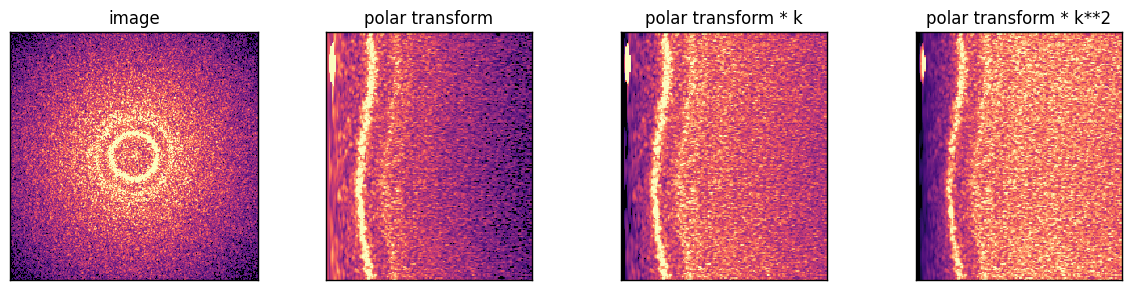

In [5]:
xind,yind = 10,10

em.visualization.show_2d(
    [
        ds.array[xind,yind],
        polar.array[xind,yind],
        polar.array[xind,yind] * polar.coords(3)[None,:],
        polar.array[xind,yind] * polar.coords(3)[None,:]**2,
    ],
    vmin = 0,
    norm = {
        'power': 0.25,
    },
    title = [
        'image',
        'polar transform',
        'polar transform * k',
        'polar transform * k**2',
    ],
    cmap='magma',
    axsize = (3,3),
)

In contrast, here is a polar transform of the same data with automated origin selection. This origin is much closer to the truth, as seen by the consistent intensities along the annular direction.

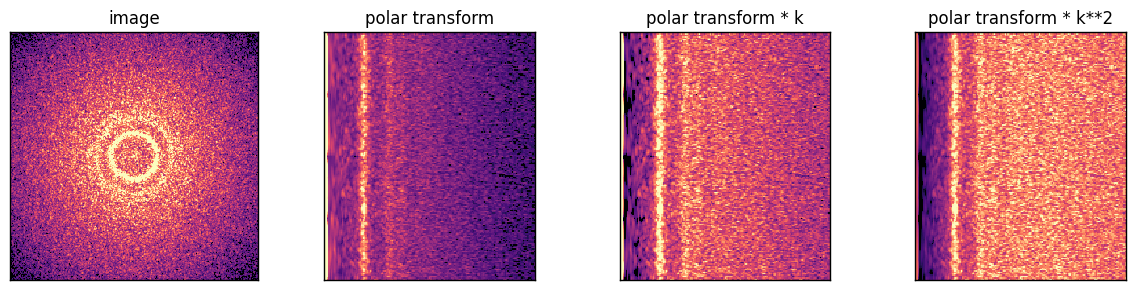

In [6]:
polar = ds.polar_transform()


xind,yind = 10,10

em.visualization.show_2d(
    [
        ds.array[xind,yind],
        polar.array[xind,yind],
        polar.array[xind,yind] * polar.coords(3)[None,:],
        polar.array[xind,yind] * polar.coords(3)[None,:]**2,
    ],
    vmin = 0,
    norm = {
        'power': 0.25,
    },
    title = [
        'image',
        'polar transform',
        'polar transform * k',
        'polar transform * k**2',
    ],
    cmap = 'magma',
    axsize = (3,3),
);

### Calculate ground truth PDF

Here, we quickly calculate a ground truth PDF from the atomic coordinates. This will later allow us to examine the PDF computed from the PDF workflow for accuracy.

In [7]:
class atoms: pass

# Define a generator function to access specific rows in the coordinate text file
def generate_specific_rows(filePath, userows=[]):
    with open(filePath, 'rb') as f:
        for i, line in enumerate(f):
            if i in userows:
                yield line

# Get cell dimensions from 2nd row of the coordinate file.  File uses Prismatic input format: https://prism-em.com/docs-inputs/
atoms.cell = np.eye(3) * np.loadtxt(
    generate_specific_rows(
        file_coords,
        userows = [1]),
    unpack='true',
)

# Read in all atomic coordinates, and then keep only (x,y,z) coordinates.
atoms.positions = np.genfromtxt(
    file_coords,
    skip_header=2,
    skip_footer=2,
)[:,1:4]

In [8]:
# Define a quick and dirty radial distribution function calculation function.
def quick_rdf(
    atoms,
    dr_ind = 1.5,
    skip = 1,
    hist_r_max = 10.0,
    hist_dr = 0.05,
    hist_sigma = 0.1,
    renormalize_reduced_pdf = True,
    plot_result = True,
    ):
    """
    Calculate the RDF in a two-stage process:
    1 - write indices into a volume to find neighbors within some range.
    2 - Compute the distribution
    """

    # Construct index volume
    vol_size = np.round(atoms.cell[(0,1,2),(0,1,2)] / dr_ind).astype('int')
    dr_ind = atoms.cell[(0,1,2),(0,1,2)] / vol_size

    x_inds = np.mod(np.round(atoms.positions[:,0] / dr_ind[0]).astype('int'), vol_size[0])
    y_inds = np.mod(np.round(atoms.positions[:,1] / dr_ind[1]).astype('int'), vol_size[1])
    z_inds = np.mod(np.round(atoms.positions[:,2] / dr_ind[2]).astype('int'), vol_size[2])


    vol = np.ma.masked_array(
        data = np.zeros(vol_size,dtype='int'),
        mask = np.ones(vol_size,dtype='bool'),
    )
    vol[x_inds,y_inds,z_inds] = np.arange(atoms.positions.shape[0])

    # Histogram coordinates
    hist_r = np.arange(0.0,hist_r_max,hist_dr)
    hist_sig = np.zeros_like(hist_r)
    num_bins = hist_r.shape[0]

    # search size
    r_search = np.ceil(hist_r_max / np.max(dr_ind)).astype('int')
    v_search = np.arange(-r_search,r_search+1)
    x_search = v_search[:,None,None]
    y_search = v_search[None,:,None]
    z_search = v_search[None,None,:]

    # Density
    volume = np.abs(np.sum(atoms.cell[:,0] * np.cross(atoms.cell[:,1], atoms.cell[:,2])))
    dens = atoms.positions.shape[0] / volume
    print('atomic density = ' + str(np.round(dens,5)))

    # loop over all coordinates
    count = 0
    for a0 in range(0,atoms.positions.shape[0],skip):
        count += 1

        inds = np.unique(vol[
            np.mod(x_inds[a0] + x_search, vol_size[0]),
            np.mod(y_inds[a0] + y_search, vol_size[1]),
            np.mod(z_inds[a0] + z_search, vol_size[2])])
        dr = np.sqrt(np.sum((atoms.positions[inds,:] - atoms.positions[a0,:])**2,axis=1))

        r_ind = dr / hist_dr
        r_floor = np.floor(r_ind).astype('int')
        dr_ind = r_ind - r_floor

        sub = r_floor < num_bins
        hist_sig += np.bincount(
            r_floor[sub],
            weights = (1-dr_ind[sub]),
            minlength = num_bins)

        sub = r_floor < num_bins-1
        hist_sig += np.bincount(
            r_floor[sub]+1,
            weights = dr_ind[sub],
            minlength = num_bins)

    hist_sig /= count

    hist_sig[0] = 0

    gr = hist_sig.copy()
    gr[1:] /=  (hist_dr*dens*4*np.pi)*hist_r[1:]**2

    if renormalize_reduced_pdf:
        scale = np.sum(gr * hist_r) / np.sum(hist_r)
        gr /= scale

    if plot_result:
        fig,ax = plt.subplots(figsize=(8,3))

        ax.plot(
            hist_r,
            gr,
            color = 'r',
        )

    return hist_r, hist_sig, gr

atomic density = 0.05284
1st NN max = 2.85 A


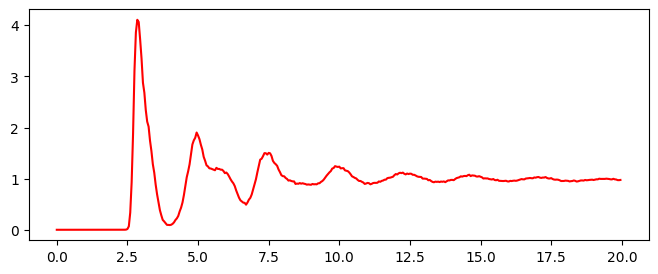

In [9]:
hist_r, hist_sig, hist_sig_reduced = quick_rdf(
    atoms,
    hist_r_max = 20,
    # hist_dr = 0.1,
    skip = 501,
)

ind_max = np.argmax(hist_sig_reduced)
print(
    '1st NN max = ' + str(hist_r[ind_max]) + ' A'
)

### Calculate pair distribution function

This module utilizes the same background model as py4dstem

TODO: add moving kernel to store results as: (xprobe, yprobe, g(r))

In [10]:
rdf = em.diffraction.PairDistributionFunction.from_data(polar)

In [11]:
rdf.calculate_pair_dist_function(
    r_max = 20.0,  
    # k_min=0.03, 
    # k_max=1.9, 
    # k_lowpass=0.02
)

**Plotting options:**
- `radial_mean`
- `background`
- `reduced_sf`
- `reduced_pdf`
- `pdf`
- `oscillation_damping`

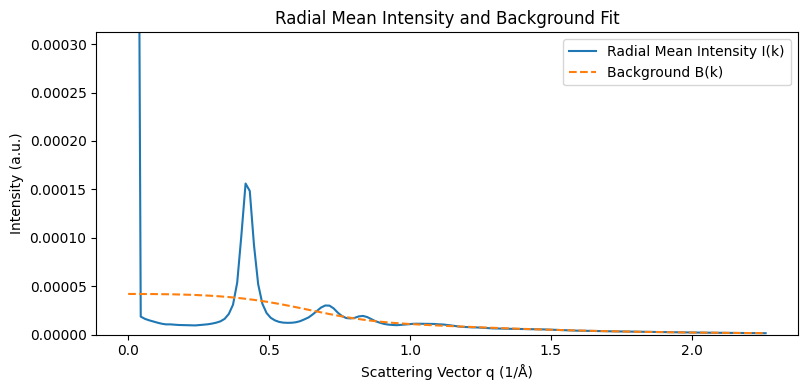

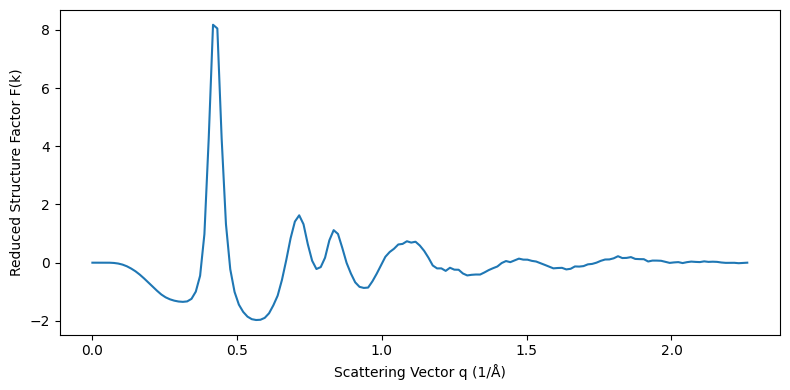

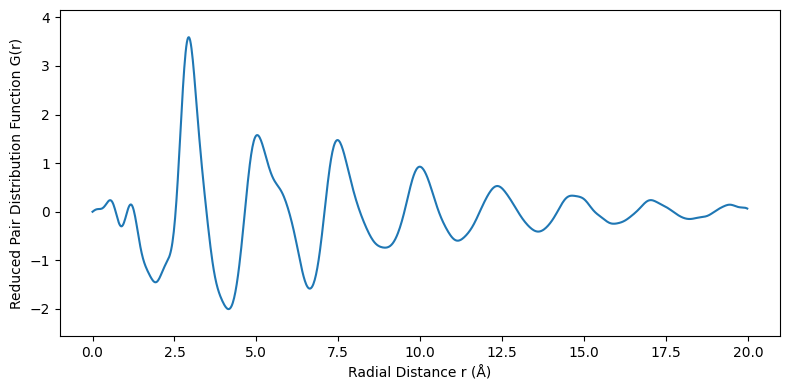

In [12]:
rdf.plot_pdf_results(
    [
        "background_fits", 
        "reduced_sf", 
        "reduced_pdf"
    ],
    # qmin = 0.1
)

### Estimate density and dampen origin oscillation

From Yoshimoto and Omote, 2022.

This optional flag works by iteratively fitting the structure factor S(k) using the density as the fitting parameter. This produces a density estimate that can be used to calculate the pdf g(r), in addition to a "corrected" S(k) and corresponding G(r) that is more physically consistent at low r.

In [13]:
r, Gr, gr  = rdf.calculate_pair_dist_function(
    r_max = 20.0,  
    # k_min=0.02, 
    # k_max=1.8, 
    # k_lowpass=0.02, 
    damp_origin_oscillations = True,
    returnval=True, 
    calculate_pdf=True,
    set_pdf_positive=True)

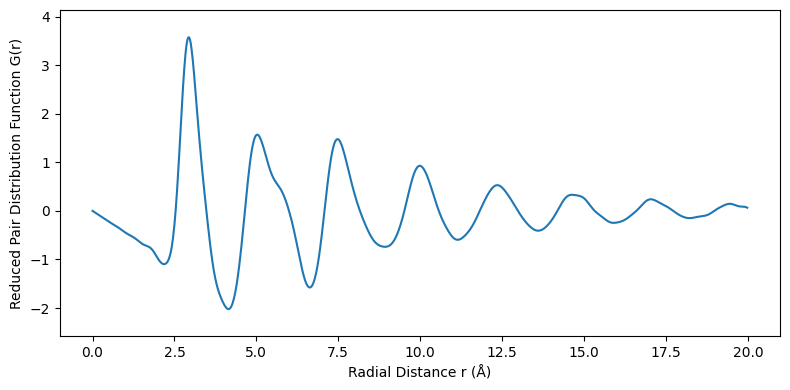

In [14]:
rdf.plot_pdf_results(
    [
        "reduced_pdf",
    ],
    # qmin = 0.1
)

Finally, we can compare the calculated PDF with our ground truth PDF from earlier:

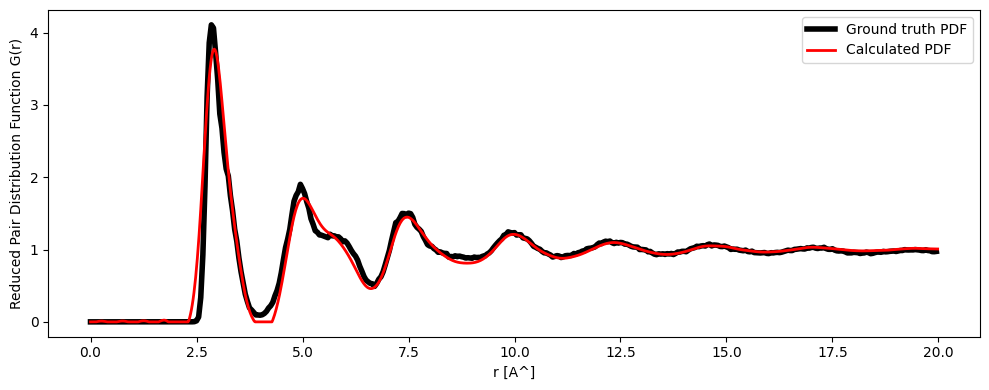

In [15]:
#Compare to a quick RDF from atomic coordinates
fig,ax = plt.subplots(figsize=(10,4))

ax.plot(
    hist_r,
    hist_sig_reduced,
    color = 'k',
    linewidth = 4,
    label = "Ground truth PDF"
)

ax.plot(
    rdf.r,
    rdf.pdf,
    color = 'r',
    linewidth = 2,
    label = "Calculated PDF"
)

ax.set_xlabel("r [A^]")
ax.set_ylabel("Reduced Pair Distribution Function G(r)")
plt.legend()
plt.tight_layout()
plt.show()

### 